In [1]:
!pip install pandas scikit-learn seaborn matplotlib wordcloud


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\hariv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv("../data/ai_news/ai_news_dataset.csv")

df = df[['text','is_misinformation']]

df = df.rename(columns={'is_misinformation':'label'})

df = df.dropna()

df.head()

,text,label
0,Sample post content 1 about AI and misinformat...,1
1,Sample post content 2 about AI and misinformat...,0
2,Sample post content 3 about AI and misinformat...,0
3,Sample post content 4 about AI and misinformat...,1
4,Sample post content 5 about AI and misinformat...,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    500 non-null    str  
 1   label   500 non-null    int64
dtypes: int64(1), str(1)
memory usage: 33.2 KB


In [5]:
df.describe()

,label
count,500.000000
mean,0.536000
std,0.499202
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


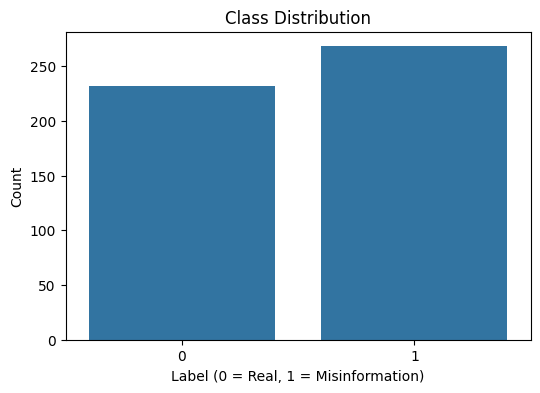

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['label'])

plt.title("Class Distribution")
plt.xlabel("Label (0 = Real, 1 = Misinformation)")
plt.ylabel("Count")

plt.show()

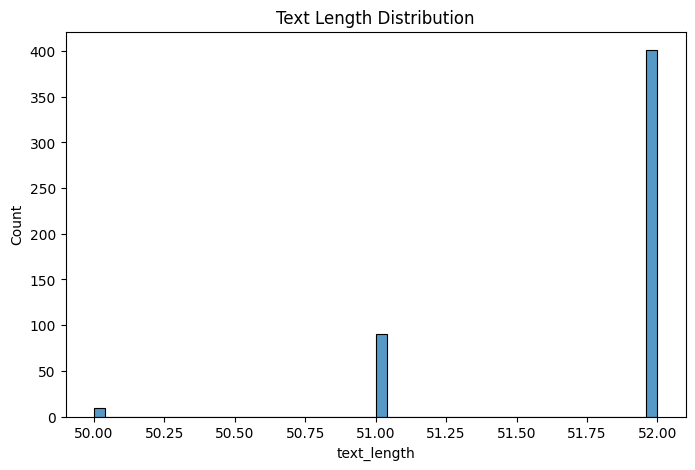

In [7]:
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df['text_length'], bins=50)

plt.title("Text Length Distribution")

plt.show()

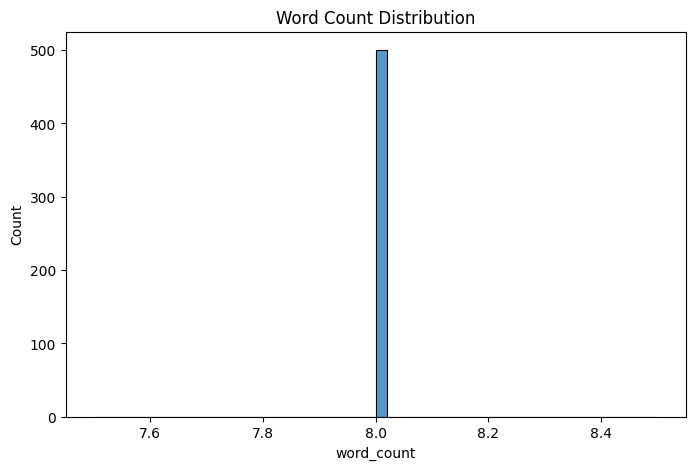

In [8]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))

sns.histplot(df['word_count'], bins=50)

plt.title("Word Count Distribution")

plt.show()

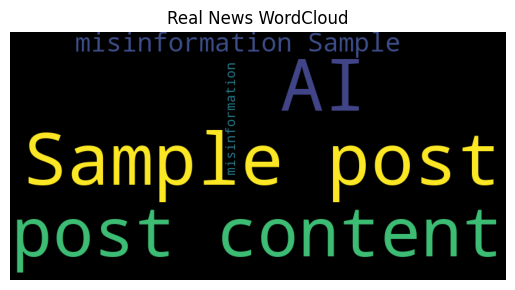

In [9]:
real_text = " ".join(df[df['label']==0]['text'])

wordcloud = WordCloud(width=800, height=400).generate(real_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Real News WordCloud")

plt.show()

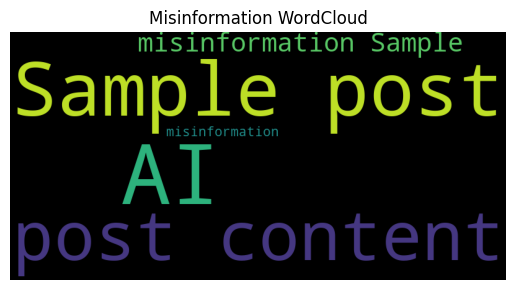

In [10]:
fake_text = " ".join(df[df['label']==1]['text'])

wordcloud = WordCloud(width=800, height=400).generate(fake_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Misinformation WordCloud")

plt.show()

In [11]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [13]:
# Logistic Regression

lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf,y_train)

pred_lr = lr_model.predict(X_test_tfidf)

print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.50      0.02      0.04        45
           1       0.55      0.98      0.71        55

    accuracy                           0.55       100
   macro avg       0.53      0.50      0.37       100
weighted avg       0.53      0.55      0.41       100



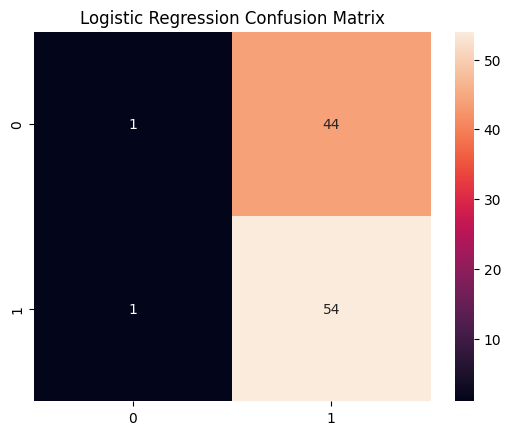

In [14]:
cm = confusion_matrix(y_test,pred_lr)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [15]:
# Support Vector Machine
svm_model = SVC(kernel='linear')

svm_model.fit(X_train_tfidf,y_train)

pred_svm = svm_model.predict(X_test_tfidf)

print(classification_report(y_test,pred_svm))

              precision    recall  f1-score   support

           0       0.50      0.02      0.04        45
           1       0.55      0.98      0.71        55

    accuracy                           0.55       100
   macro avg       0.53      0.50      0.37       100
weighted avg       0.53      0.55      0.41       100



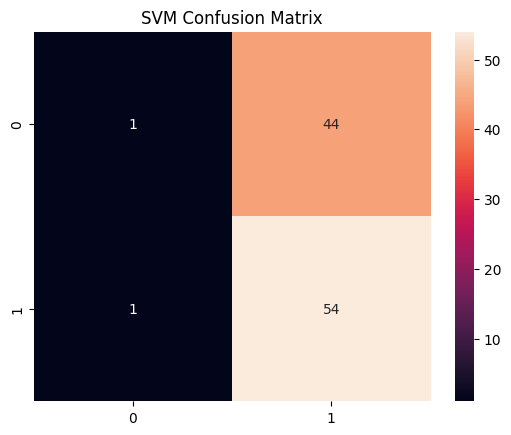

In [16]:
cm = confusion_matrix(y_test,pred_svm)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("SVM Confusion Matrix")

plt.show()

In [17]:
# Random Forest

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train_tfidf,y_train)

pred_rf = rf_model.predict(X_test_tfidf)

print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.45      1.00      0.62        45
           1       0.00      0.00      0.00        55

    accuracy                           0.45       100
   macro avg       0.23      0.50      0.31       100
weighted avg       0.20      0.45      0.28       100



C:\Users\hariv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hariv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hariv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

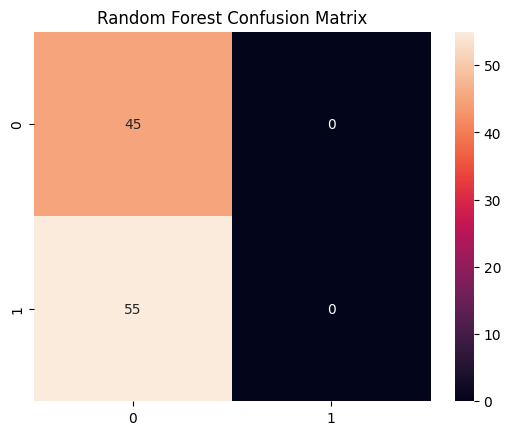

In [18]:
cm = confusion_matrix(y_test,pred_rf)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Random Forest Confusion Matrix")

plt.show()

Model Accuracy Comparison

In [19]:
acc_lr = accuracy_score(y_test,pred_lr)
acc_svm = accuracy_score(y_test,pred_svm)
acc_rf = accuracy_score(y_test,pred_rf)

results = pd.DataFrame({
    "Model":["Logistic Regression","SVM","Random Forest"],
    "Accuracy":[acc_lr,acc_svm,acc_rf]
})

results

,Model,Accuracy
0,Logistic Regression,0.55
1,SVM,0.55
2,Random Forest,0.45


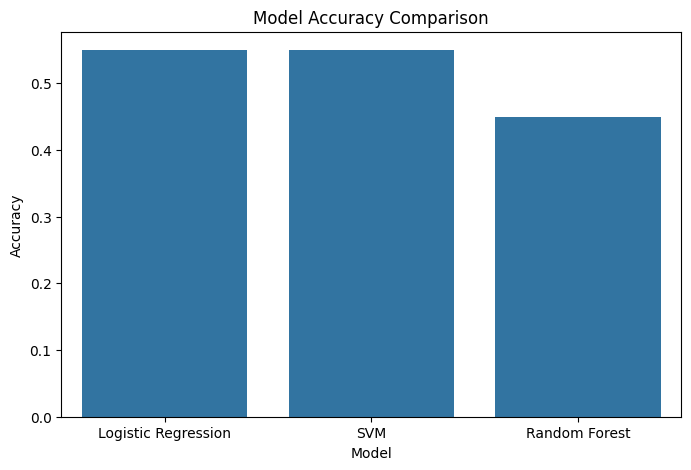

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model",y="Accuracy",data=results)

plt.title("Model Accuracy Comparison")

plt.show()

In [21]:
import pickle

pickle.dump(rf_model, open("../models/ai_models/random_forest_model.pkl","wb"))